In [1]:
import torch 
import matplotlib.pyplot as plt 

%matplotlib inline

In [2]:
names = open("./names.txt", "r").read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
characters = sorted(set("".join(names)))
stoi = {c:i+1 for i, c in enumerate(characters)}
stoi["."] = 0
itos = {i:c for c, i in stoi.items()}
total_unique_chars_in_dataset = len(characters)+1


In [4]:
# turn text into training dataset 

BLOCK_SIZE = 3
X,Y = [],[]

for w in names:
    
    context = [0] * BLOCK_SIZE
    
    for ch in (w+"."):
        
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        
        context = context[1:]+[ix]

X = torch.tensor(X)
Y = torch.tensor(Y)
X.shape, Y.shape, X, Y

(torch.Size([228146, 3]),
 torch.Size([228146]),
 tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         ...,
         [26, 26, 25],
         [26, 25, 26],
         [25, 26, 24]]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [5]:
# Embedding Lookup Table 

embedding_dim = 2 
EMBEDDING_TABLE = torch.randn((total_unique_chars_in_dataset, embedding_dim))
EMBEDDING_TABLE[:3]

tensor([[ 0.0313, -0.5315],
        [ 0.5800, -2.2202],
        [ 1.0856,  1.1329]])

In [6]:
# prepare the dataset X to their embedding value and to get the embedded valued dataset 
EMBEDDED_X = EMBEDDING_TABLE[X]
EMBEDDED_X[:3] # this would be initialized embedded X 

tensor([[[ 0.0313, -0.5315],
         [ 0.0313, -0.5315],
         [ 0.0313, -0.5315]],

        [[ 0.0313, -0.5315],
         [ 0.0313, -0.5315],
         [ 0.7208, -0.2168]],

        [[ 0.0313, -0.5315],
         [ 0.7208, -0.2168],
         [ 0.1283, -0.2339]]])

In [7]:
# Shuffle and Splitting the dataset: train, dev, test :: 0.8 : 0.1 : 0.1

# Shuffling
RANDOM_SEED = 4204902034
g = torch.Generator().manual_seed(RANDOM_SEED)
perm = torch.randperm(X.shape[0], generator=g)
X_shuffle, Y_shuffle = X[perm], Y[perm]

# Splitting

dataset_len = X_shuffle.shape[0]
n1 = int(0.8 * dataset_len)
n2 = int(0.9 * dataset_len)

X_train, Y_train = X_shuffle[:n1], Y_shuffle[:n1]
X_dev, Y_dev = X_shuffle[n1:n2], Y_shuffle[n1:n2]
X_test, Y_test = X_shuffle[n2:], Y_shuffle[n2:]


In [8]:
print("Splitted Result: \n")
print(f"{X_train.shape=}, {Y_train.shape=}\n{X_dev.shape=}, {Y_dev.shape=}\n{X_test.shape=}, {Y_test.shape=}")

Splitted Result: 

X_train.shape=torch.Size([182516, 3]), Y_train.shape=torch.Size([182516])
X_dev.shape=torch.Size([22815, 3]), Y_dev.shape=torch.Size([22815])
X_test.shape=torch.Size([22815, 3]), Y_test.shape=torch.Size([22815])


In [10]:
# Hidden Layer 1 
Total_Neurons_H1 = 150
W1 = torch.randn((embedding_dim * BLOCK_SIZE, Total_Neurons_H1), generator=g)
b1 = torch.randn(W1.shape[1], generator=g)

# Hidden Layer 2
total_out_logits = total_unique_chars_in_dataset
W2 = torch.randn((W1.shape[1], total_out_logits), generator=g)
b2 = torch.randn(W2.shape[1], generator=g)


In [11]:
# parameters
parameters = [EMBEDDING_TABLE, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True 
    
sum(p.nelement() for p in parameters)

5181

In [16]:
print(X_train.shape, W1.shape, parameters[0].dtype)
print(f"{X_train[:2]=}")
print(f"{ W1[:1]=}")

torch.Size([182516, 3]) torch.Size([6, 150]) torch.float32
X_train[:2]=tensor([[13, 15, 14],
        [ 0,  0,  0]])
 W1[:1]=tensor([[ 0.6728,  1.0213,  0.1454,  1.9667, -0.1669,  0.2538,  1.3052,  1.7288,
         -1.3521,  0.2034,  0.6243, -0.2764, -0.8548, -0.6164,  0.9744,  0.2704,
         -1.0344,  0.4790,  0.0603, -0.3904, -0.0067,  0.1643, -0.5203,  1.2805,
          0.8229, -0.9945,  0.1911, -0.5449,  1.3172, -0.5787, -1.0716, -0.7440,
          0.6189,  0.4696, -0.0562,  0.7793, -0.4934,  0.6839, -1.2166, -1.5699,
          1.3186,  0.8694,  0.5220,  0.1339, -0.6250, -0.0598, -2.0891, -2.2876,
          0.2640, -1.7297, -0.5478, -0.5026,  0.2681,  1.5533, -1.1410,  1.6640,
          2.2859, -0.6071, -0.0750,  1.6787,  1.0551,  0.7755, -0.6871,  0.6783,
          1.8627, -0.0616,  0.6491,  0.7697,  0.5978, -0.0807,  1.5486,  0.9978,
         -0.6973,  1.4815,  0.0656,  1.4235, -1.9239, -0.7434,  0.2060,  0.9035,
          0.6407,  1.1838, -0.0769,  0.7459, -1.3918,  0.0519, -1.

In [19]:
losses = []

In [89]:

# Training loops
learning_rate = 0.1 
iterations = 10000
batch_size = 32

for i in range(iterations):
    
    # -- batching 
    batch_ix = torch.randint(0, X_train.shape[0], (batch_size,)) # [32]
    X_train_batch_emb = EMBEDDING_TABLE[X_train[batch_ix]] # [32,3,2]
    Y_train_batch = Y_train[batch_ix] # [32]
    
    # -- flatten context embeddings 
    X_train_batch_emb_flat = X_train_batch_emb.view(-1, W1.shape[0])
    
    # forward pass
    h = torch.tanh(X_train_batch_emb_flat @ W1 + b1 ) # hidden layer 
    logits = h @ W2 + b2 # output logits 
    # -- calculate negative log-likelihood
    loss = torch.nn.functional.cross_entropy(logits, Y_train_batch) 
    
    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update
    with torch.no_grad():
        for p in parameters:
            p -= learning_rate * p.grad
    
    losses.append(loss.item())
    if iterations >= 1000 and i%1000 == 0:
        print(f"iteration: {i+1}: {loss=}")
    

iteration: 1: loss=tensor(2.6591, grad_fn=<NllLossBackward0>)
iteration: 1001: loss=tensor(1.7079, grad_fn=<NllLossBackward0>)
iteration: 2001: loss=tensor(2.0348, grad_fn=<NllLossBackward0>)
iteration: 3001: loss=tensor(2.1461, grad_fn=<NllLossBackward0>)
iteration: 4001: loss=tensor(2.2507, grad_fn=<NllLossBackward0>)
iteration: 5001: loss=tensor(2.2776, grad_fn=<NllLossBackward0>)
iteration: 6001: loss=tensor(2.5622, grad_fn=<NllLossBackward0>)
iteration: 7001: loss=tensor(2.2458, grad_fn=<NllLossBackward0>)
iteration: 8001: loss=tensor(2.0613, grad_fn=<NllLossBackward0>)
iteration: 9001: loss=tensor(2.2764, grad_fn=<NllLossBackward0>)


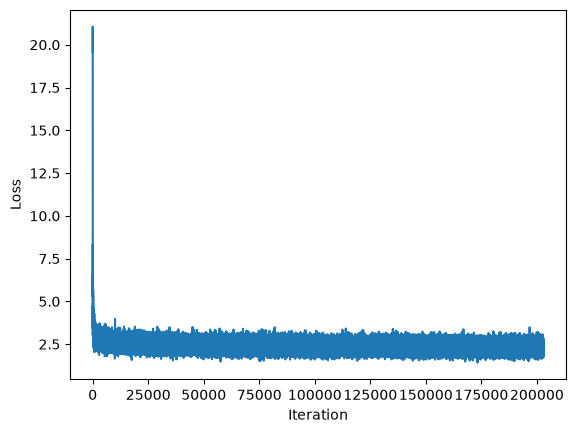

In [90]:
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

In [91]:
# testing
X_test_emb = EMBEDDING_TABLE[X_test]
X_test_emb_flat = X_test_emb.view(-1, W1.shape[0])
test_h = torch.tanh( X_test_emb_flat @ W1 + b1)
test_logits = test_h @ W2 + b2
test_loss = torch.nn.functional.cross_entropy(test_logits, Y_test)
print(f"{test_loss=}")

test_loss=tensor(2.3843, grad_fn=<NllLossBackward0>)


In [92]:
X_dev_emb = EMBEDDING_TABLE[X_dev]
X_dev_emb_flat = X_dev_emb.view(-1, W1.shape[0])
dev_h = torch.tanh( X_dev_emb_flat @ W1 + b1)
dev_logits = dev_h @ W2 + b2
dev_loss = torch.nn.functional.cross_entropy(dev_logits, Y_dev)
print(f"{dev_loss=}")

dev_loss=tensor(2.3977, grad_fn=<NllLossBackward0>)
